In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time
from physical_diffusion_fns.network_fns import setup_general_polynomial_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE  

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.3, .7])

# Define means
means = jnp.array([
    [1., 1.],   # mean of first Gaussian
    [-1., -1.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

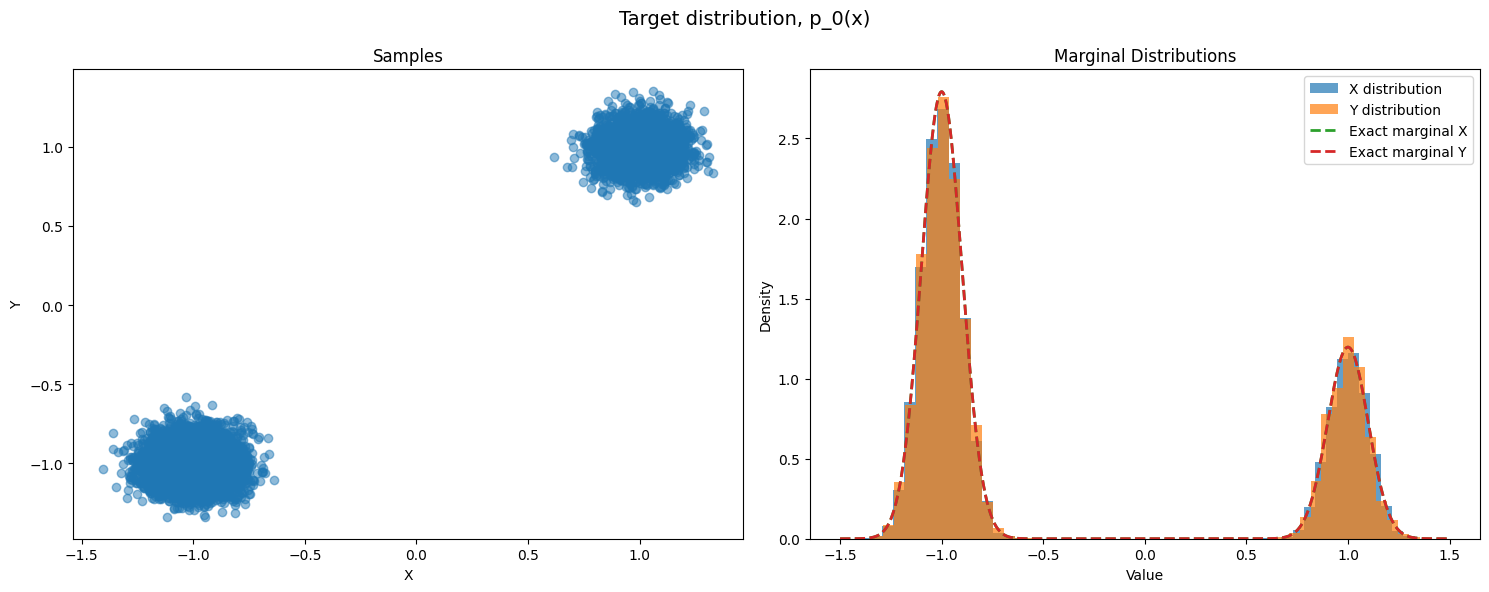

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Network size and topology

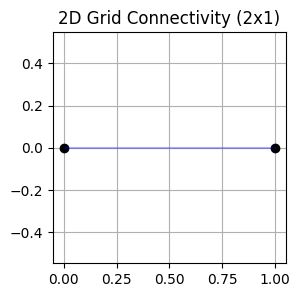

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
a1_0 = jnp.array([1.])
a2_0 = jnp.array([1.])
a3_0 = jnp.array([1.])
bias_0 = jnp.array([0.,0.,])
params_initial = (a1_0, a2_0, a3_0, bias_0)
params_names = ["a1", "a2", "a3", "external_force"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)

### Build energy

In [6]:
energy_fn = setup_general_polynomial_network_with_external_force_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


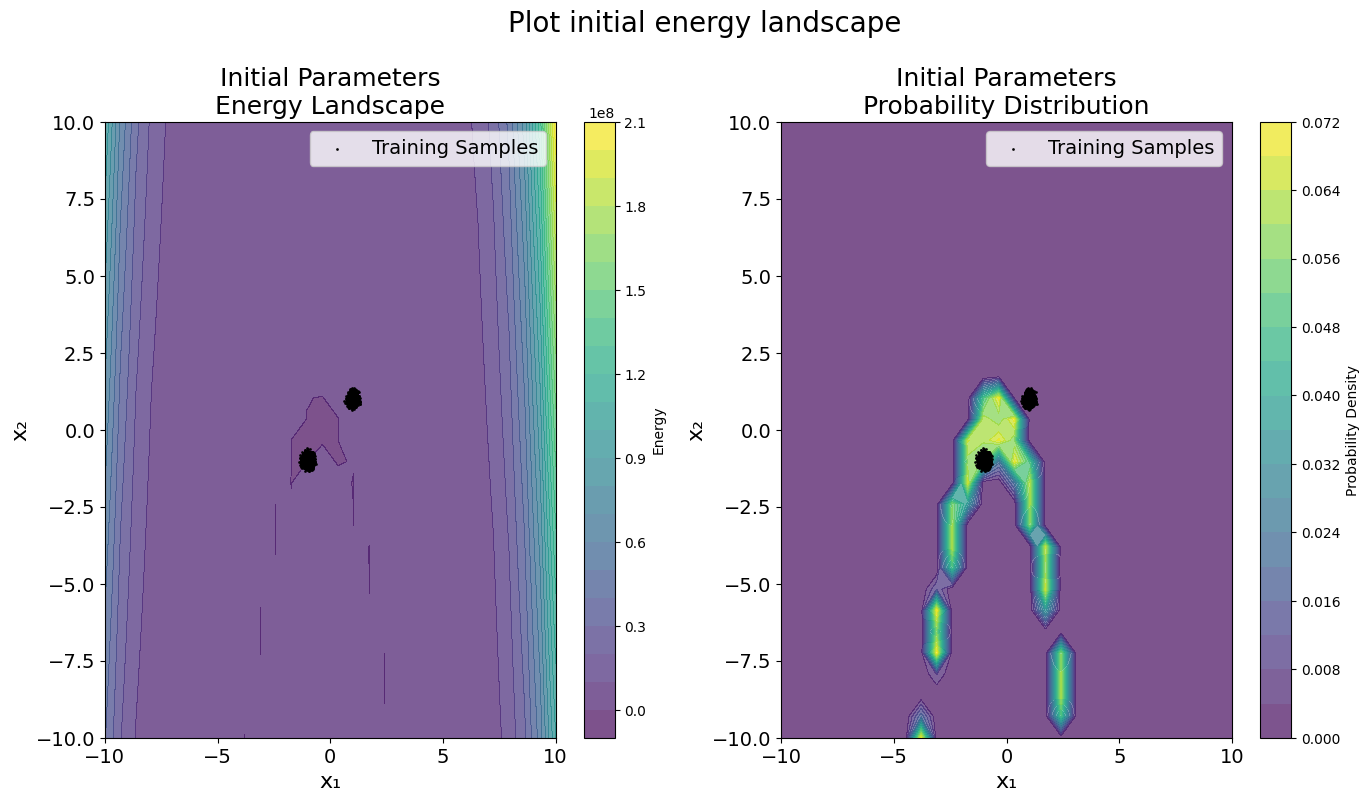

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-10, 10),   
    x2_range=(-10, 10),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 50
t_forward = 1.0
sigma_forward = .5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = .01
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = "with_external_force"
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.3 0.7]_means_[ 1.  1. -1. -1.]_covs_[0.01 0.   0.   0.01 0.01 0.   0.   0.01]/SM_t_forward_1.0_n_timesteps_50_lr_0.01_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_with_external_force


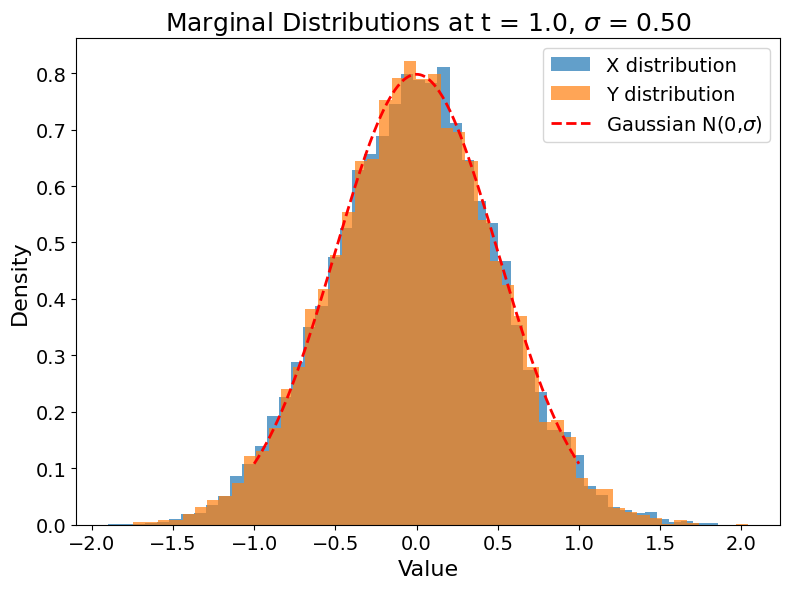

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: 21662.8586
Epoch 100 - Loss: 223.5700
Epoch 200 - Loss: 59.8900
Epoch 300 - Loss: 30.5886
Epoch 400 - Loss: 12.7173
Epoch 500 - Loss: 4.2092
Epoch 600 - Loss: 1.1705
Epoch 700 - Loss: -1.1275
Epoch 800 - Loss: -2.1937
Epoch 900 - Loss: -3.0113
Epoch 1000 - Loss: -2.9620
Epoch 1100 - Loss: -2.2012
Epoch 1200 - Loss: -4.3167
Epoch 1300 - Loss: -3.8840
Epoch 1400 - Loss: -3.6722
Epoch 1500 - Loss: -3.7207
Epoch 1600 - Loss: -3.9088
Epoch 1700 - Loss: -4.9351
Epoch 1800 - Loss: -3.8691
Epoch 1900 - Loss: -3.7831
Epoch 2000 - Loss: -4.5432
Epoch 2100 - Loss: -4.1906
Epoch 2200 - Loss: -3.5089
Epoch 2300 - Loss: -3.4975
Epoch 2400 - Loss: -3.0579
Epoch 2500 - Loss: -4.0652
Epoch 2600 - Loss: -4.4653
Epoch 2700 - Loss: -4.5563
Epoch 2800 - Loss: -4.0095
Epoch 2900 - Loss: -4.1560
Epoch 3000 - Loss: -3.9644
Epoch 3100 - Loss: -4.2583
Epoch 3200 - Loss: -3.6374
Epoch 3300 - Loss: -4.8555
Epoch 3400 - Loss: -3.5667
Epoch 3500 - Loss: -4.0239
Epoch 3600 -

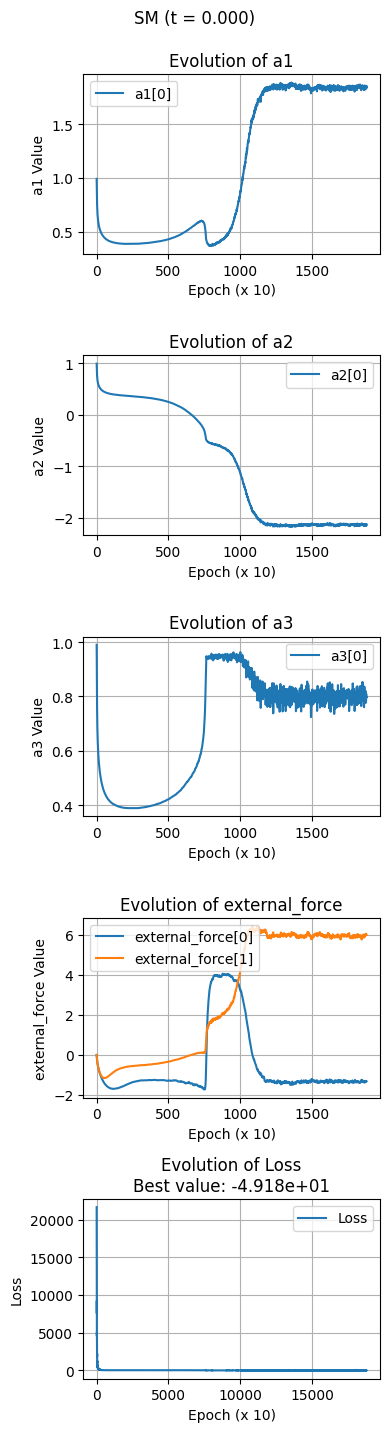

Optimization for time 1.5264179671752362e-09
Epoch 0 - Loss: -41.1850
Epoch 100 - Loss: -31.5070
Epoch 200 - Loss: -36.1359
Epoch 300 - Loss: -39.8597
Epoch 400 - Loss: -40.2589
Epoch 500 - Loss: -31.1134
Epoch 600 - Loss: -14.6139
Epoch 700 - Loss: -37.1741
Epoch 800 - Loss: -28.4101
Epoch 900 - Loss: -37.1139
Epoch 1000 - Loss: -34.4344
Epoch 1100 - Loss: -25.7931
Epoch 1200 - Loss: -31.6527
Epoch 1300 - Loss: -31.4652
Epoch 1400 - Loss: -39.9615
Epoch 1500 - Loss: -27.5806
Epoch 1600 - Loss: -34.3135
Epoch 1700 - Loss: -39.9928
Epoch 1800 - Loss: -35.3610
Epoch 1900 - Loss: -35.3664
Epoch 2000 - Loss: -16.5512
Epoch 2100 - Loss: -24.3421
Epoch 2200 - Loss: -31.9043
Epoch 2300 - Loss: -27.1609
Epoch 2400 - Loss: -23.7708
Epoch 2500 - Loss: -38.6348
Epoch 2600 - Loss: -14.0807
Epoch 2700 - Loss: -34.5188
Epoch 2800 - Loss: -24.7864
Epoch 2900 - Loss: -31.6798
Epoch 3000 - Loss: -36.3990
Epoch 3100 - Loss: -33.1332
Epoch 3200 - Loss: -30.0371
Epoch 3300 - Loss: -33.9185
Epoch 3400 - Lo

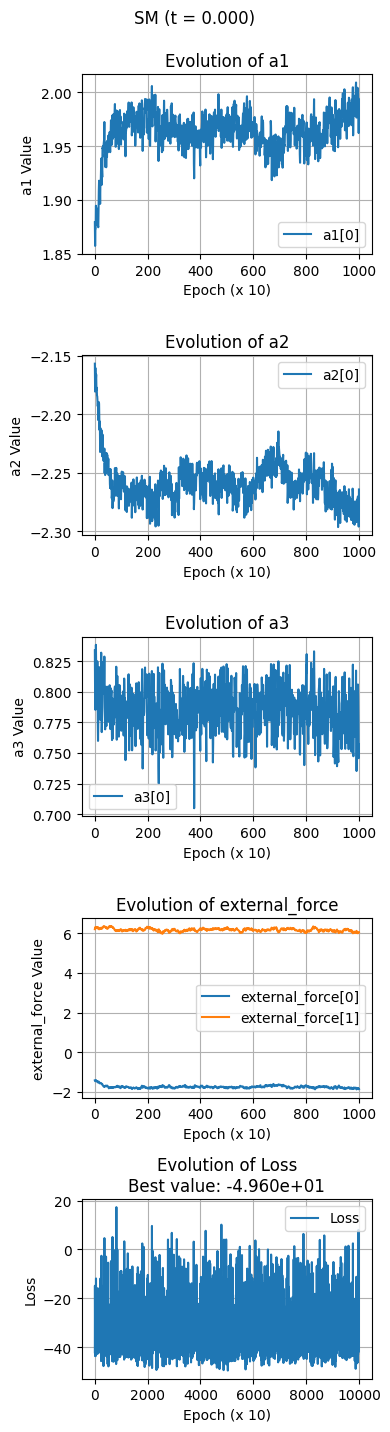

Optimization for time 1.0481131341546869e-07
Epoch 0 - Loss: -28.9839
Epoch 100 - Loss: -25.4050
Epoch 200 - Loss: -34.1023
Epoch 300 - Loss: -34.3452
Epoch 400 - Loss: -43.3606
Epoch 500 - Loss: -41.5871
Epoch 600 - Loss: -30.8527
Epoch 700 - Loss: -42.2604
Epoch 800 - Loss: -40.1204
Epoch 900 - Loss: -39.5834
Epoch 1000 - Loss: -30.4142
Epoch 1100 - Loss: -25.3843
Epoch 1200 - Loss: -36.9599
Epoch 1300 - Loss: -36.6431
Epoch 1400 - Loss: -28.5574
Epoch 1500 - Loss: -29.4710
Epoch 1600 - Loss: -37.6095
Epoch 1700 - Loss: -36.2539
Epoch 1800 - Loss: -13.7632
Epoch 1900 - Loss: -19.2910
Epoch 2000 - Loss: -29.4430
Epoch 2100 - Loss: -44.2494
Epoch 2200 - Loss: -33.7861
Epoch 2300 - Loss: -20.2095
Epoch 2400 - Loss: -33.9567
Epoch 2500 - Loss: -39.2158
Epoch 2600 - Loss: -36.2959
Epoch 2700 - Loss: -38.3152
Epoch 2800 - Loss: -32.2030
Epoch 2900 - Loss: -38.5198
Epoch 3000 - Loss: -36.8292
Epoch 3100 - Loss: -30.4884
Epoch 3200 - Loss: -39.8550
Epoch 3300 - Loss: -34.9835
Epoch 3400 - Lo

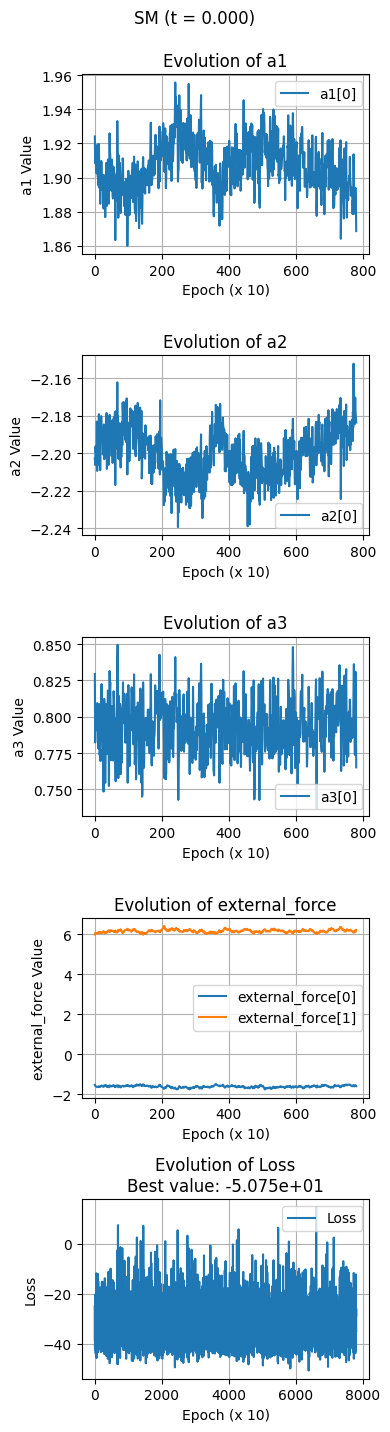

Optimization for time 7.19685673001151e-06
Epoch 0 - Loss: -12.6681
Epoch 100 - Loss: -36.4192
Epoch 200 - Loss: -38.9453
Epoch 300 - Loss: -27.5318
Epoch 400 - Loss: -26.5070
Epoch 500 - Loss: -34.6028
Epoch 600 - Loss: -42.9058
Epoch 700 - Loss: -7.3451
Epoch 800 - Loss: -36.0266
Epoch 900 - Loss: -36.5709
Epoch 1000 - Loss: -32.5046
Epoch 1100 - Loss: -33.0946
Epoch 1200 - Loss: -28.6605
Epoch 1300 - Loss: -40.0028
Epoch 1400 - Loss: -32.7941
Epoch 1500 - Loss: -30.4543
Epoch 1600 - Loss: -35.5226
Epoch 1700 - Loss: -13.0330
Epoch 1800 - Loss: -21.3597
Epoch 1900 - Loss: -37.8349
Epoch 2000 - Loss: -43.9701
Epoch 2100 - Loss: -28.0174
Epoch 2200 - Loss: -28.5139
Epoch 2300 - Loss: -35.2441
Epoch 2400 - Loss: -31.0481
Epoch 2500 - Loss: -39.7780
Epoch 2600 - Loss: -38.6372
Epoch 2700 - Loss: -38.2341
Epoch 2800 - Loss: -30.5579
Epoch 2900 - Loss: -34.9585
Epoch 3000 - Loss: -45.4365
Epoch 3100 - Loss: -31.4631
Epoch 3200 - Loss: -36.7346
Epoch 3300 - Loss: -39.8769
Epoch 3400 - Loss:

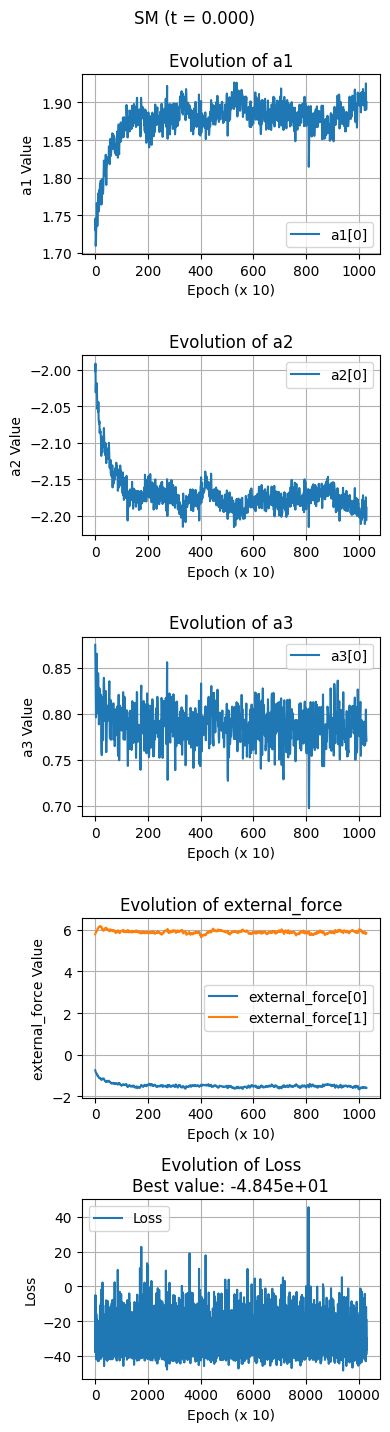

Optimization for time 0.0004941713361323828
Epoch 0 - Loss: -21.4535
Epoch 100 - Loss: -28.9830
Epoch 200 - Loss: -27.3493
Epoch 300 - Loss: -34.8767
Epoch 400 - Loss: -32.4095
Epoch 500 - Loss: -25.6458
Epoch 600 - Loss: -36.3513
Epoch 700 - Loss: -34.9773
Epoch 800 - Loss: -22.2380
Epoch 900 - Loss: -30.1627
Epoch 1000 - Loss: -11.3922
Epoch 1100 - Loss: -26.1401
Epoch 1200 - Loss: -31.5556
Epoch 1300 - Loss: -23.1580
Epoch 1400 - Loss: -29.7594
Epoch 1500 - Loss: -35.3884
Epoch 1600 - Loss: -21.5895
Epoch 1700 - Loss: -28.5239
Epoch 1800 - Loss: -26.4567
Epoch 1900 - Loss: -29.8659
Epoch 2000 - Loss: -35.8329
Epoch 2100 - Loss: -30.3137
Epoch 2200 - Loss: -32.6309
Epoch 2300 - Loss: -23.7099
Epoch 2400 - Loss: -34.7156
Epoch 2500 - Loss: -34.9528
Epoch 2600 - Loss: -30.1400
Epoch 2700 - Loss: -26.2683
Epoch 2800 - Loss: -30.6128
Epoch 2900 - Loss: -19.7777
Epoch 3000 - Loss: -27.6625
Epoch 3100 - Loss: -32.7210
Epoch 3200 - Loss: -27.3923
Epoch 3300 - Loss: -26.5413
Epoch 3400 - Los

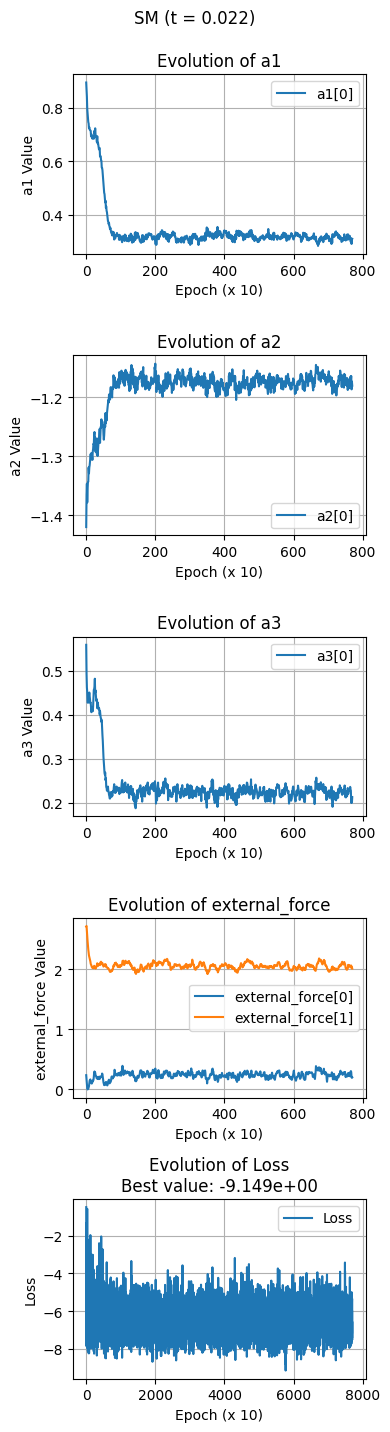

Optimization for time 0.03393221771895324
Epoch 0 - Loss: -5.1559
Epoch 100 - Loss: -5.3911
Epoch 200 - Loss: -5.0365
Epoch 300 - Loss: -5.1429
Epoch 400 - Loss: -4.6758
Epoch 500 - Loss: -5.7535
Epoch 600 - Loss: -4.1506
Epoch 700 - Loss: -5.0511
Epoch 800 - Loss: -5.1992
Epoch 900 - Loss: -5.8584
Epoch 1000 - Loss: -4.9556
Epoch 1100 - Loss: -4.8860
Epoch 1200 - Loss: -5.1484
Epoch 1300 - Loss: -5.6228
Epoch 1400 - Loss: -5.5567
Epoch 1500 - Loss: -4.4410
Epoch 1600 - Loss: -4.6729
Epoch 1700 - Loss: -5.0388
Epoch 1800 - Loss: -5.6468
Epoch 1900 - Loss: -5.8735
Epoch 2000 - Loss: -3.5888
Epoch 2100 - Loss: -3.9257
Epoch 2200 - Loss: -4.7826
Epoch 2300 - Loss: -4.9998
Epoch 2400 - Loss: -3.6699
Epoch 2500 - Loss: -5.9434
Epoch 2600 - Loss: -4.7597
Epoch 2700 - Loss: -3.2263
Epoch 2800 - Loss: -4.8886
Epoch 2900 - Loss: -5.4910
Epoch 3000 - Loss: -3.2703
Epoch 3100 - Loss: -5.8567
Epoch 3200 - Loss: -4.9214
Epoch 3300 - Loss: -4.0862
Epoch 3400 - Loss: -4.5534
Epoch 3500 - Loss: -5.276

In [13]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.zeros(params_flattened_initial.shape[0])
    mask = mask.at[0].set(1.)
    mask = mask.at[1].set(1.)
    mask = mask.at[2].set(1.)
    mask = mask.at[3].set(0.)
    mask = mask.at[-1].set(1.0)
    mask = mask.at[-2].set(1.0)

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

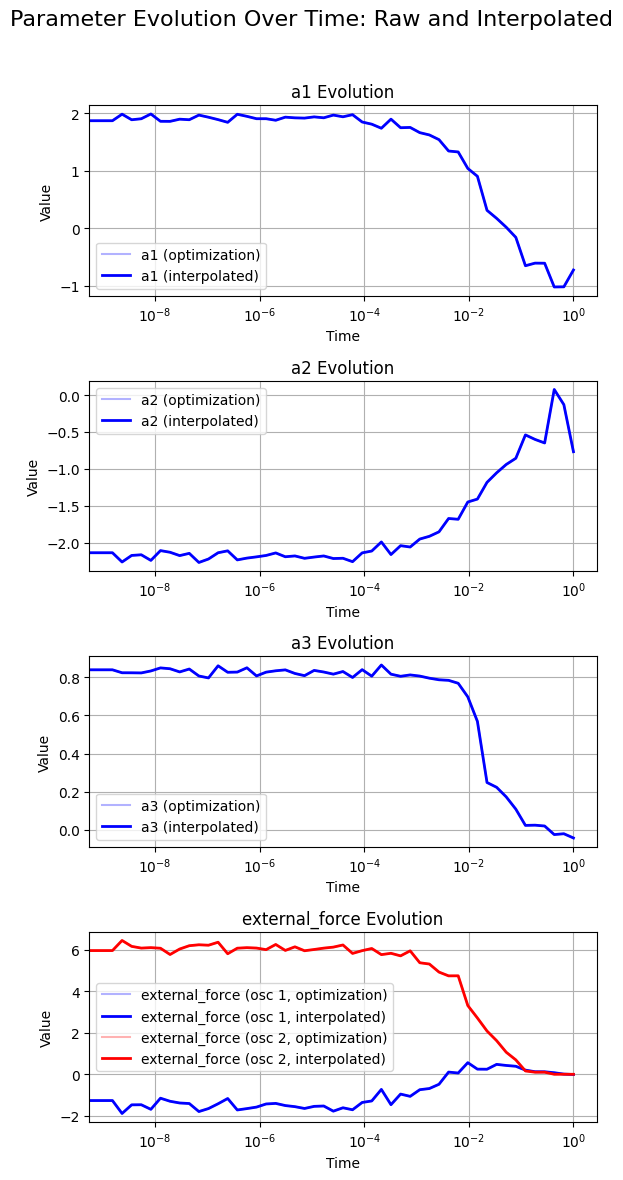

In [14]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [10, 10, 10, 10, 10, 10, 10, 10], poly_orders = [3, 3, 3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)


plot_parameter_as_fn_of_time(params_names, forward_time_pts,forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc) 

# Sampling via reverse SDE

In [15]:
params_interpolator_reverse = lambda t: 2*params_interpolator(t_forward - t)

def setup_energy_backwards_fn(connectivity, unflatten, sigma_forward):
    def energy_backwards_fn(x, flattened_args):
        base_energy = energy_fn(x, flattened_args)
        additional_energy = 0.5 * (1/sigma_forward) * jnp.sum(x**2)
        return base_energy + additional_energy

    return energy_backwards_fn
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse, N_osc, time_dependent_parms=True)

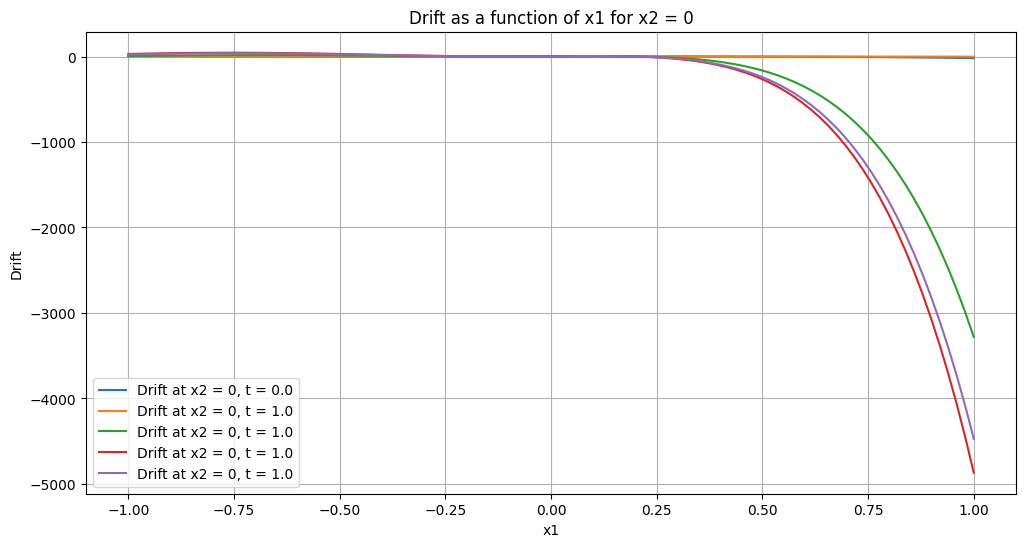

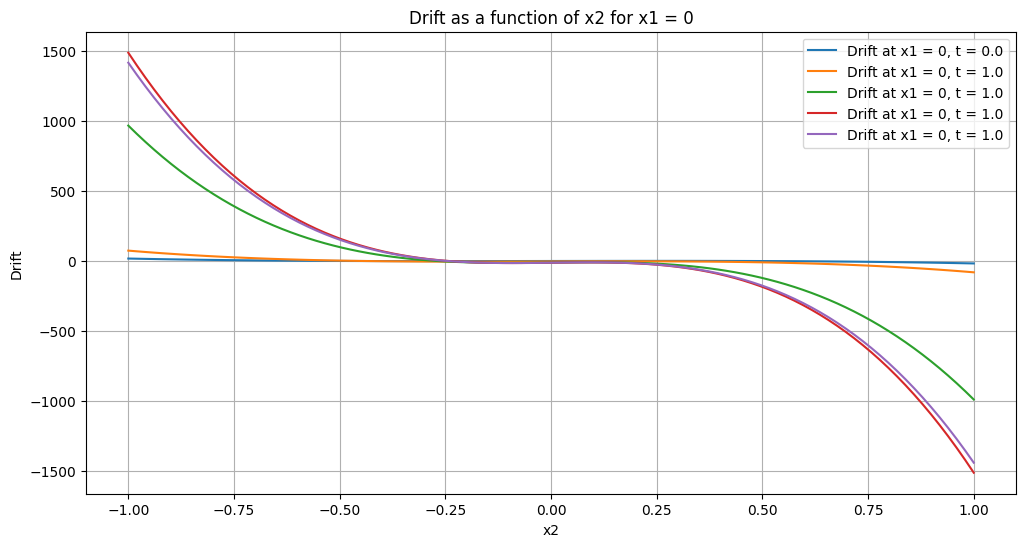

In [16]:
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
n_trajectories = 2000
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=1, samples0=samples_0, key=subkey)
# Sample initial conditions from N(0, I)
# n_trajectories = 1000  # or any other number of trajectories you need
# n_dimensions = 2  # assuming 2D, adjust as necessary
# key, subkey = jr.split(key)
# initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [18]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


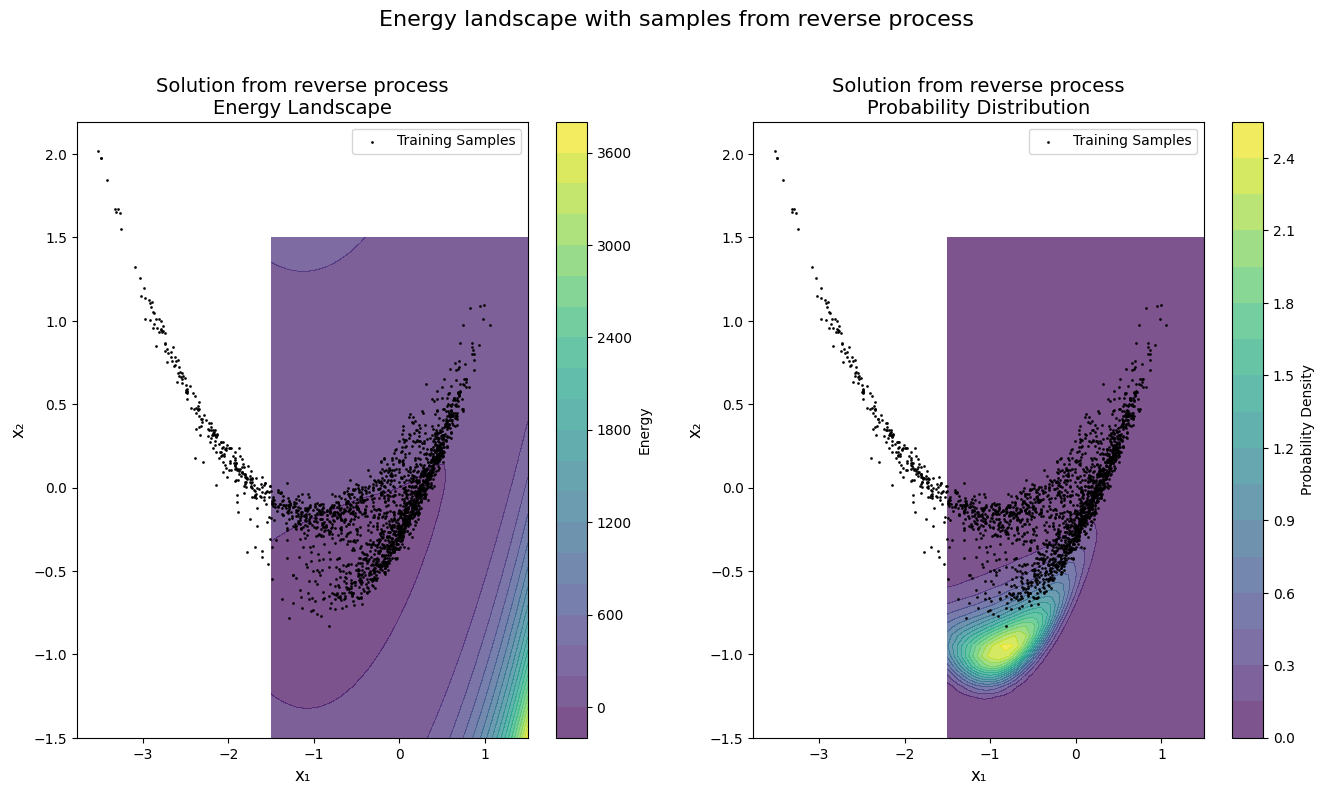

In [19]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


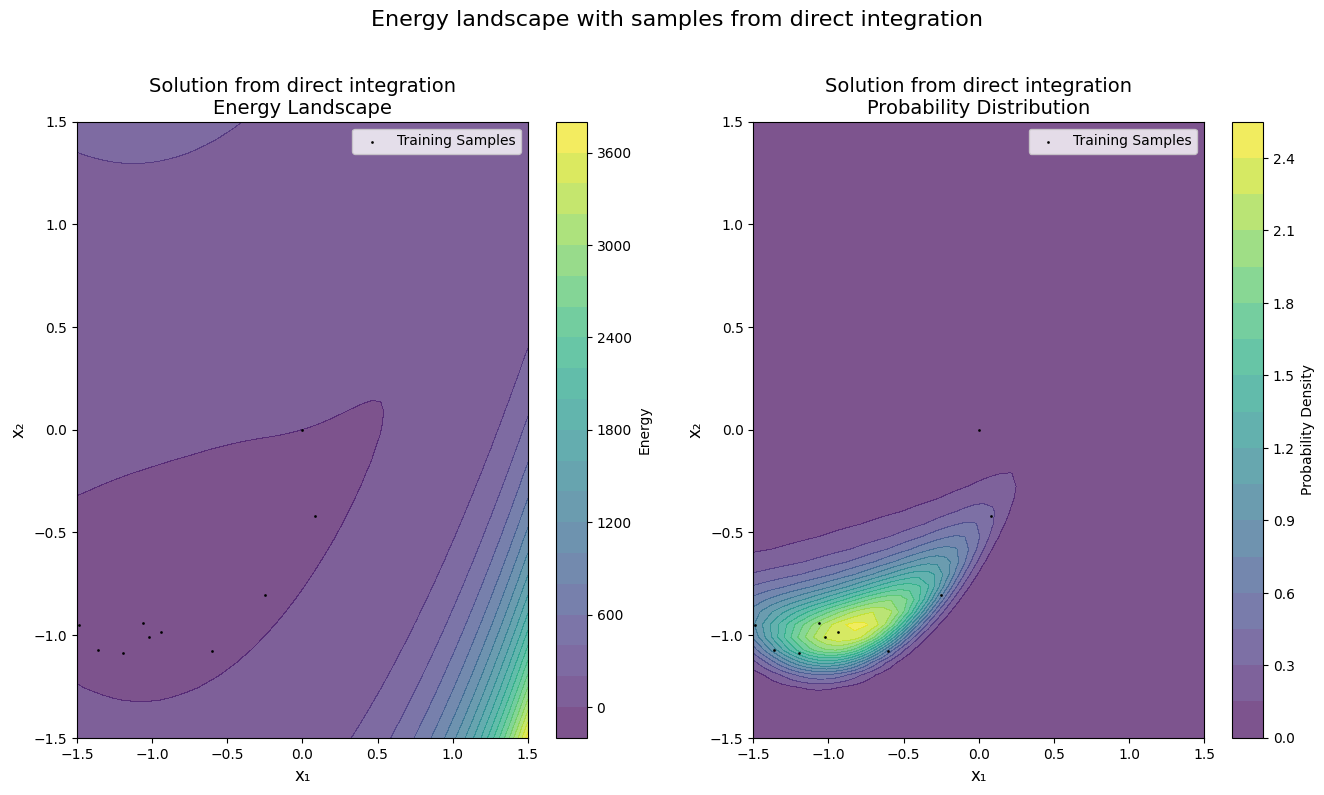

In [20]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=100,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

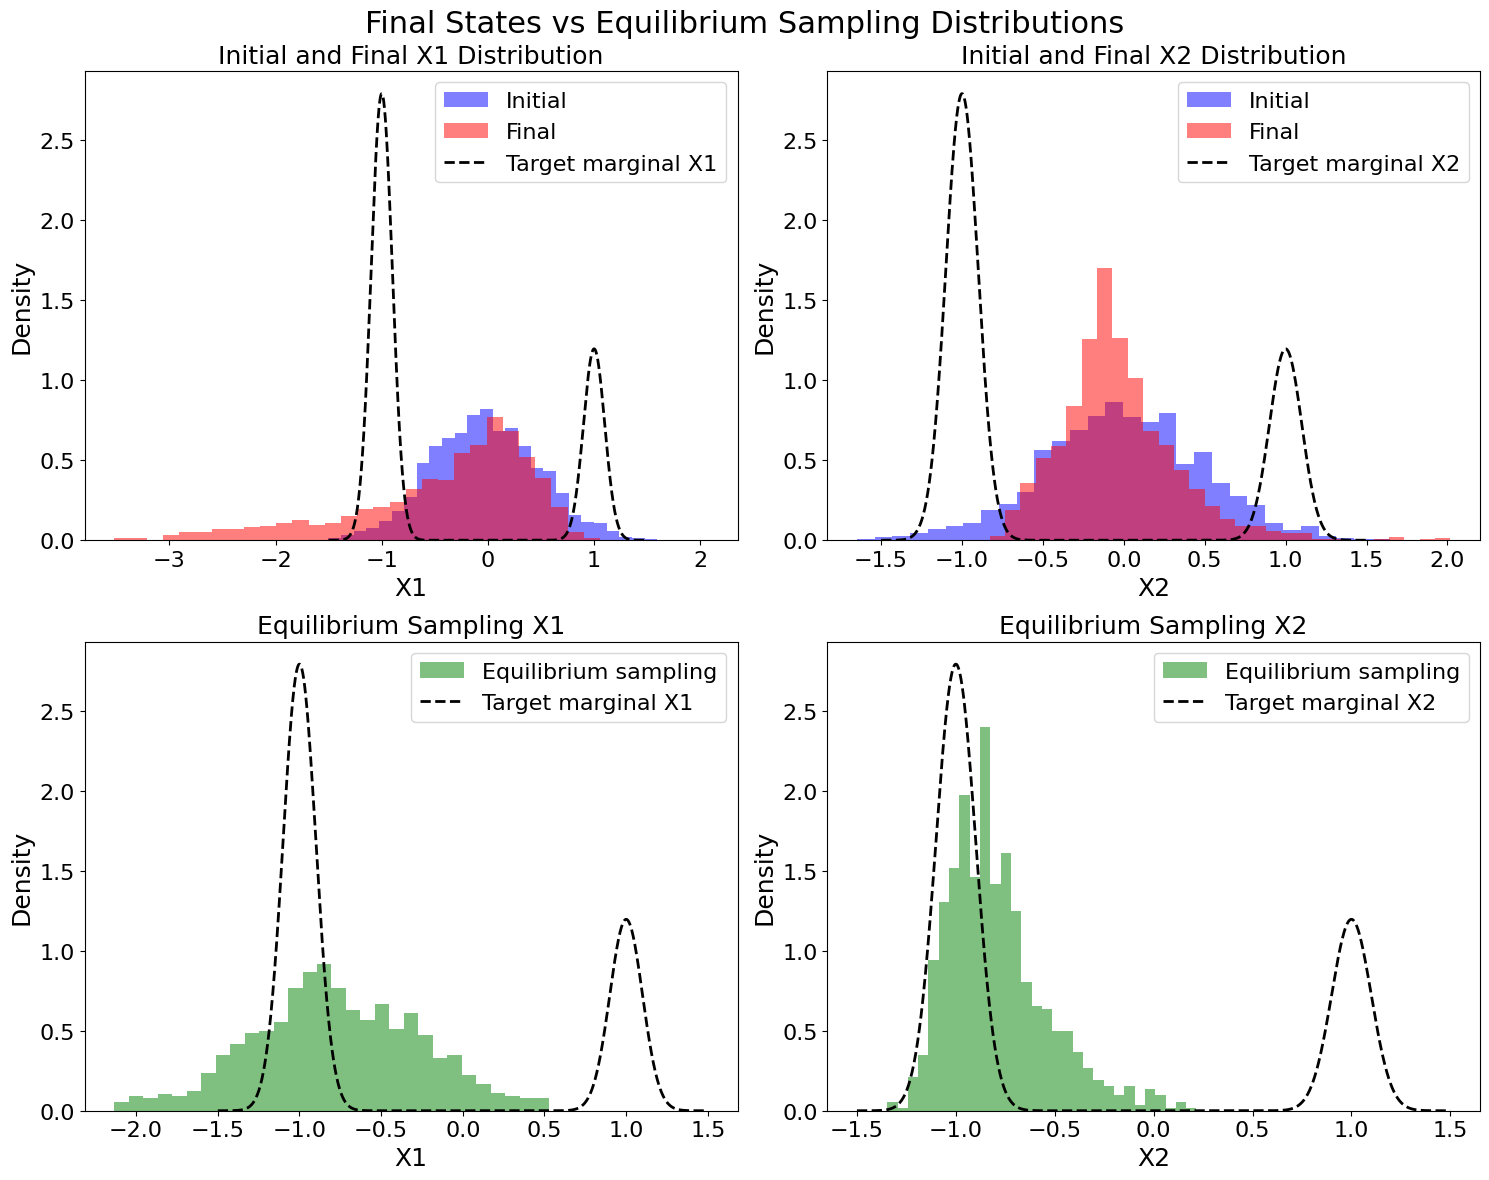

In [21]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()